In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset_path = os.path.join("..", "dataset")

train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")
test_path = os.path.join(dataset_path, "test")

In [3]:
IMG_SIZE = 224

### Read and Resize One Image

In [4]:
normal_path = os.path.join(train_path, "NORMAL")

image = os.listdir(normal_path)[0]

img = cv2.imread(os.path.join(normal_path, image))

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

print(img.shape)

(224, 224, 3)


In [5]:
img = img / 255.0

print(img.min())
print(img.max())

0.0
1.0


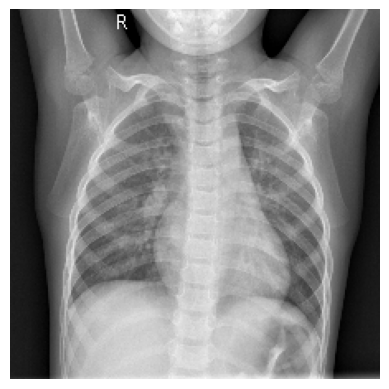

In [6]:
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
images = []
labels = []

classes = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}
print(classes)

for cls, label in classes.items():
    folder = os.path.join(train_path, cls)

    print("Class:", cls)
    print("Label:", label)
    print("Images:", len(os.listdir(folder)))
    print("-" * 30)

for cls, label in classes.items():

    folder = os.path.join(train_path, cls)

    for file in os.listdir(folder):

        img_path = os.path.join(folder, file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        img = img / 255.0

        images.append(img)
        labels.append(label)

x_train = np.array(images, dtype=np.float32)
y_train = np.array(labels)

print("x_train Shape :",x_train.shape)
print("y_train Shape :", y_train.shape)



{'NORMAL': 0, 'PNEUMONIA': 1}
Class: NORMAL
Label: 0
Images: 1341
------------------------------
Class: PNEUMONIA
Label: 1
Images: 3875
------------------------------
X_train Shape : (5216, 224, 224, 3)
y_train Shape : (5216,)


In [28]:
y_train

array([0, 0, 0, ..., 1, 1, 1], shape=(5216,))

In [26]:
print(np.unique(y_train))

[0 1]


In [27]:
print("NORMAL:", np.sum(y_train == 0))
print("PNEUMONIA:", np.sum(y_train == 1))

NORMAL: 1341
PNEUMONIA: 3875


In [31]:
print(y_train[-20:])
print(y_train[1335:1345])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 1 1 1 1]


In [ ]:
label_map = {
    0: "NORMAL",
    1: "PNEUMONIA"
}
print(label_map)

{0: 'NORMAL', 1: 'PNEUMONIA'}


In [10]:
print(x_train.min())
print(x_train.max())

print(np.unique(y_train))

0.0
1.0
[0 1]
